<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos Bayesianos: Muestreo de Thompson y UCB Bayesiano

*Description:* El estudio compara el rendimiento de algoritmos Ballesianos (Muestreo de Thompson y UCB Bayesiano) en un problema de k-armed bandit.

* **Muestreo de Thompson**: Muestrea de la distribución Beta de cada brazo y selecciona el que tenga el mayor valor. Se actualiza α y β en función del éxito o fracaso.

* **UCB Bayesiano**: Calcula un intervalo superior de confianza basado en la media y varianza de la distribución Beta, ajustado por un factor γ.

Se generan gráficas diversas para cada algoritmo.

## Preparación del entorno


In [31]:
#@title Copiar el repositorio.

#!git clone github.com/aalonsopuig/k_brazos_AAPGAG.git
#!cd eml_k_bandit/

In [32]:
#@title Importamos todas las clases y funciones

import sys

# Añadir el directorio fuente al path de Python
sys.path.append('src')

# Verificar que se ha añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, ThompsonSampling, BayesianUCB
from arms import ArmNormal, ArmBernoulli, ArmBinomial, ArmBeta, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos.

Este código ejecuta múltiples simulaciones de un problema de bandido k-brazos utilizando distintos algoritmos, calcula las recompensas promedio y el porcentaje de selecciones óptimas a lo largo de los pasos de tiempo

In [33]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Ejecuta un experimento de multi-armed bandit para evaluar diferentes algoritmos.

    Parámetros:
    bandit: Instancia del problema Bandit, que contiene las probabilidades de recompensa de cada brazo.
    algorithms: Lista de algoritmos de selección de brazos a comparar.
    steps: Número de pasos (iteraciones) que se ejecutarán por cada corrida.
    runs: Número de veces que se repetirá el experimento para obtener promedios.

    Devuelve:
    rewards: Matriz con las recompensas promedio obtenidas por cada algoritmo en cada paso.
    optimal_selections: Matriz con el porcentaje de veces que cada algoritmo seleccionó el brazo óptimo.
    """
    
    optimal_arm = bandit.optimal_arm  # Identifica el brazo con la mejor recompensa esperada

    rewards = np.zeros((len(algorithms), steps))  # Inicializa matriz para acumular recompensas
    optimal_selections = np.zeros((len(algorithms), steps))  # Inicializa matriz para contar selecciones óptimas

    np.random.seed(seed)  # Fija la semilla para reproducibilidad

    for run in range(runs):  # Itera por cada corrida del experimento
        current_bandit = Bandit(arms=bandit.arms)  # Crea una nueva instancia del bandit para cada corrida

        for algo in algorithms:
            algo.reset()  # Reinicia el estado de cada algoritmo

        for step in range(steps):  # Itera por cada paso dentro de una corrida
            for idx, algo in enumerate(algorithms):  # Itera por cada algoritmo
                chosen_arm = algo.select_arm()  # El algoritmo selecciona un brazo
                reward = current_bandit.pull_arm(chosen_arm)  # Se obtiene la recompensa al tirar de ese brazo
                algo.update(chosen_arm, reward)  # El algoritmo actualiza su estrategia con el nuevo dato

                rewards[idx, step] += reward  # Acumula la recompensa obtenida en este paso para este algoritmo

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1  # Incrementa el contador si el brazo elegido fue el óptimo

    rewards /= runs  # Calcula el promedio de recompensas por cada paso y algoritmo
    optimal_selections = (optimal_selections / runs) * 100  # Convierte las selecciones óptimas a porcentaje

    return rewards, optimal_selections  # Devuelve las matrices de recompensas y selecciones óptimas

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución seleccionada (**Bernoulli** por defecto). Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 2 algoritmos UCB (UCB1 y UCB2)

In [34]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

Aunque todo el estudio está basado en bandidos de **distribución Bernoulli**, están implementadas también las **distribuciones Normal, Binomial, y Beta**. Para usarlas en este experimento tan solo hay que quitar la almohadilla (#) de la que se desee ejecutar a continuación.

In [35]:
# Creación del bandit
#bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
bandit = Bandit(arms=ArmBernoulli.generate_arms(k))  # Crear un bandido con k brazos de distribución Bernoulli
#bandit = Bandit(arms=ArmBinomial.generate_arms(k))  # Crear un bandido con k brazos de distribución Binomial
#bandit = Bandit(arms=ArmBeta.generate_arms(k))  # Crear un bandido con k brazos de distribución Beta
print(bandit)

Bandit with 10 arms: ArmBernoulli(p=0.4), ArmBernoulli(p=0.86), ArmBernoulli(p=0.22), ArmBernoulli(p=0.69), ArmBernoulli(p=0.58), ArmBernoulli(p=0.15), ArmBernoulli(p=0.79), ArmBernoulli(p=0.67), ArmBernoulli(p=0.12), ArmBernoulli(p=0.88)


In [36]:

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definimos los algoritmos a comparar: Thompson Sampling y Bayesian UCB.
# Thompson Sampling emplea muestreo bayesiano para explorar-explotar de manera probabilística.
# Bayesian UCB usa una variante bayesiana del enfoque Upper Confidence Bound.
#
# Elección de parámetros:
# - alpha = 1, beta = 1 en Thompson Sampling: Se inicia con una distribución Beta(1,1), es decir,
#   una distribución uniforme, lo que representa máxima incertidumbre inicial sobre cada brazo.
#   A medida que se obtienen más muestras, la distribución se actualiza para reflejar la evidencia.
#
# - gamma = 1 en Bayesian UCB: Este parámetro controla cuántas desviaciones estándar se usan 
#   para calcular el límite superior de confianza. Un valor de 1 implica una exploración moderada,
#   mientras que valores más altos favorecen más exploración.
algorithms = [ThompsonSampling(k=k, alpha=1, beta=1), BayesianUCB(k=k, gamma=1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 10 with expected reward=0.88


## Visualización de los resultados

### Recompensa Promedio vs Pasos de Tiempo.
Muestra cómo evolucionan las recompensas promedio obtenidas por cada algoritmo a lo largo de los pasos de tiempo.

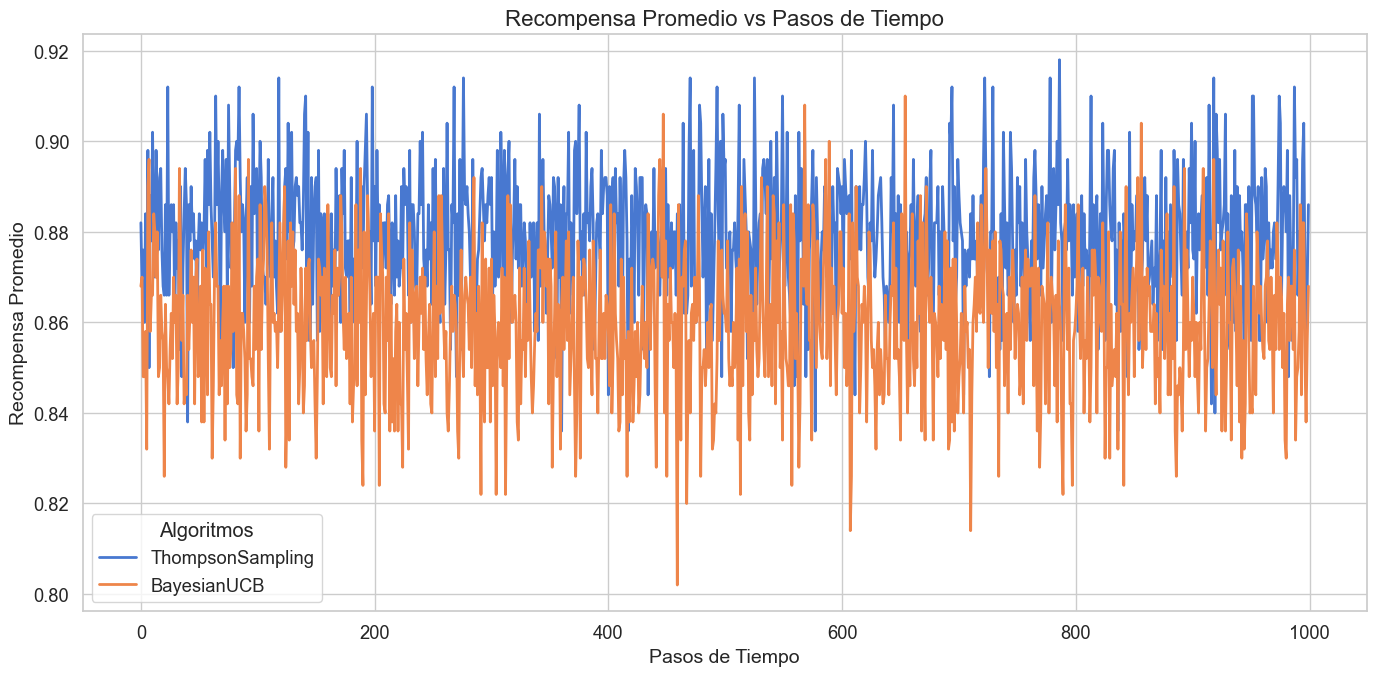

In [37]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)  # Recompensa promedio a lo largo del tiempo

#### Análisis de las gráficas


TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO 




### Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo.
Esta métrica indica cuántas veces los algoritmos seleccionan el mejor brazo disponible.

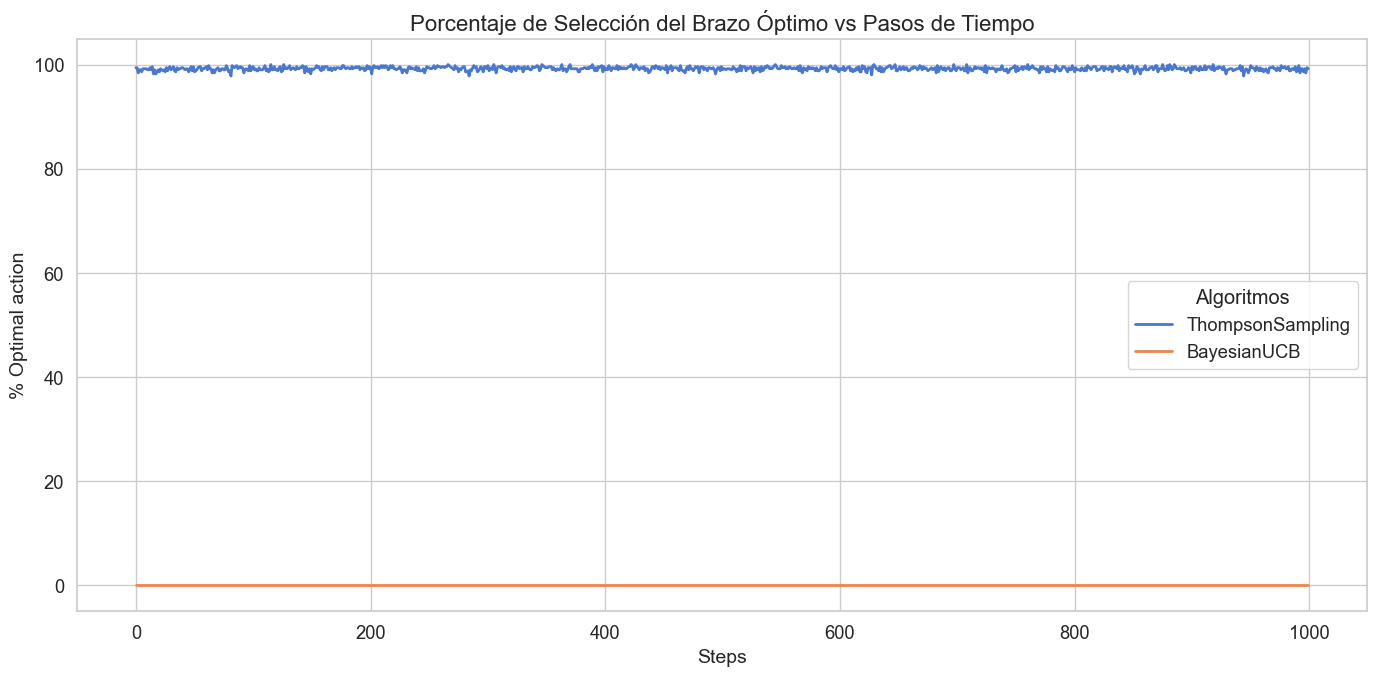

In [38]:
# Graficar la selección del brazo óptimo a lo largo del tiempo
plot_optimal_selections(steps, optimal_selections, algorithms)


#### Análisis de las gráficas



TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO 




### Estadísticas de cada brazo

Cada valor en el eje X representará un brazo. En el eje Y se representa el promedio de las ganancias de cada brazo. El gráfico mostrará un histograma para cada brazo donde se muestre el promedio de las ganancias obtenidas pero en el eje X, como etiqueta, se mostrará también el número de veces que fue seleccionado el brazo e indicar si es el brazo óptimo o no (estrella dorada).

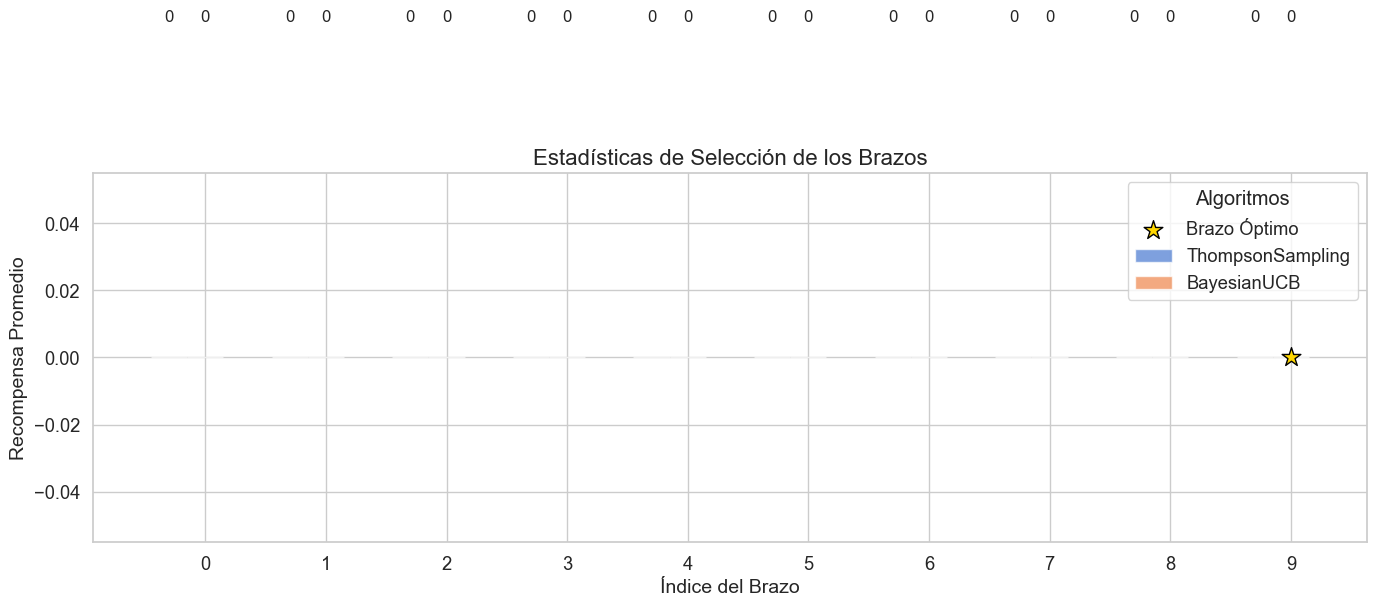

In [39]:
# Preparar los datos para la gráfica de estadísticas de brazos
arm_stats = []
for algo in algorithms:
    stats = {
        "means": algo.values,  # Recompensa promedio estimada por cada brazo
        "counts": algo.counts   # Número de veces que se seleccionó cada brazo
    }
    arm_stats.append(stats)

# Graficar estadísticas de los brazos, pasando el índice del brazo óptimo
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


#### Análisis de las gráficas





TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO 






### Evolución del rechazo

Muestra la evolución del rechazo, de forma análoga a cómo se muestra la evolución de las recompensas.

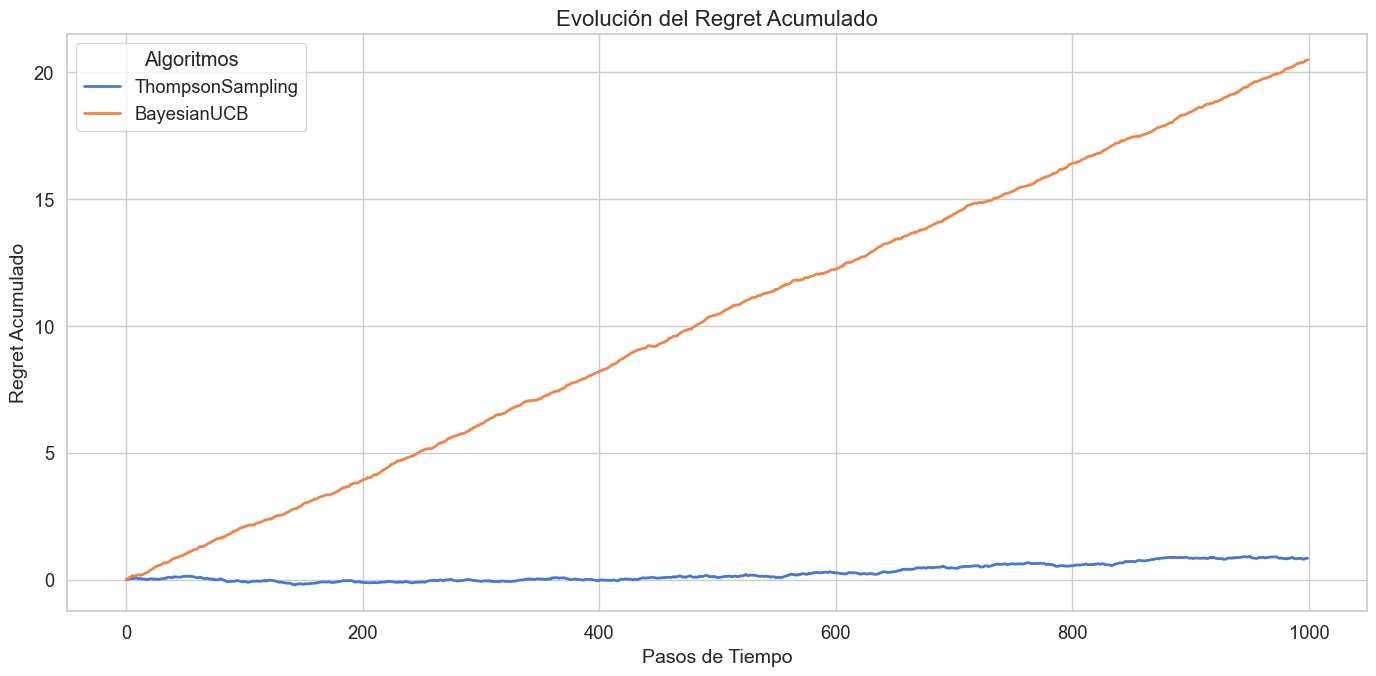

In [40]:
# Calcular el regret acumulado
optimal_reward = bandit.get_expected_value(optimal_arm)
regret_accumulated = np.cumsum(optimal_reward - rewards, axis=1)  # Regret acumulado por algoritmo

# Graficar la evolución del regret acumulado
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis de las gráficas





TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO 



